# Notebook-A10 (Data Visualization-3)

In [13]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset into Pandas DataFrame
df = pd.read_csv('iris.csv')
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [3]:
# Features & their datatypes
print("Feature and their types:")
df.dtypes

Feature and their types:


sepal.length    float64
sepal.width     float64
petal.length    float64
petal.width     float64
variety          object
dtype: object

Here, the 4 features i.e. 'sepal_length', 'sepal_width', 'petal_length',
 'petal_width' have Numerical data while 'variety' has 
nominal/categorical.

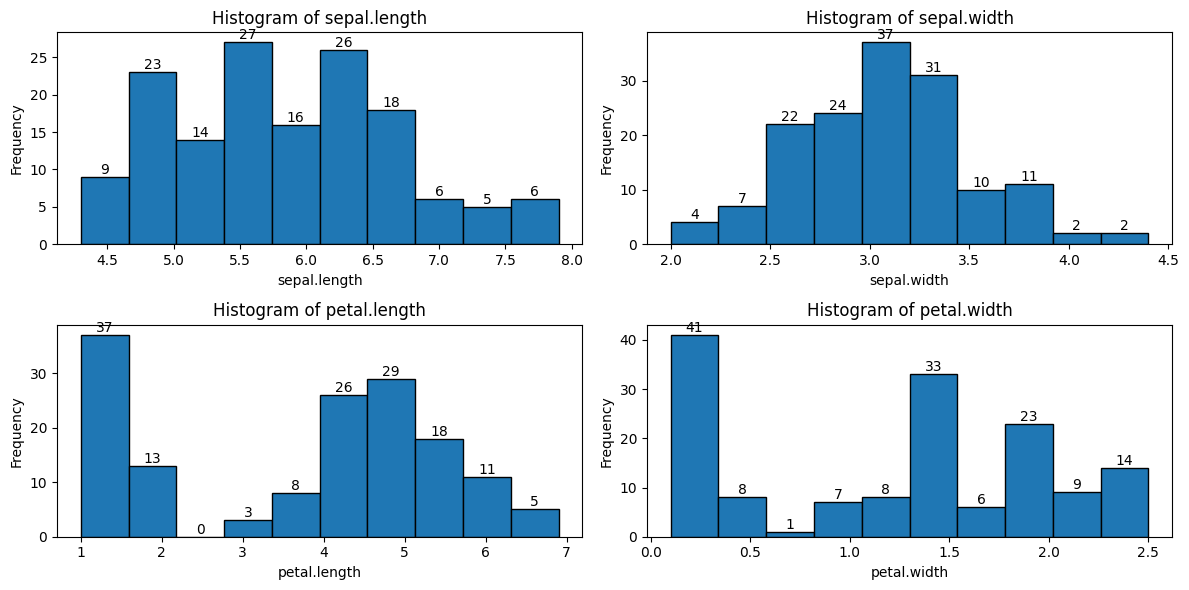

In [14]:
# Histogram for each numerical feature
plt.figure(figsize=(12, 6))

for i, column in enumerate(df.columns[:-1]):  # Exclude 'species' column
    plt.subplot(2, 2, i + 1)

    ax = plt.hist(df[column], edgecolor="black")
    plt.gca().bar_label(plt.gca().containers[0], fmt='%d')  # Add count labels
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

A histogram is a graphical representation of the distribution of a 
dataset, where data is grouped into bins, and the height of each bar 
represents the frequency of values within each bin.

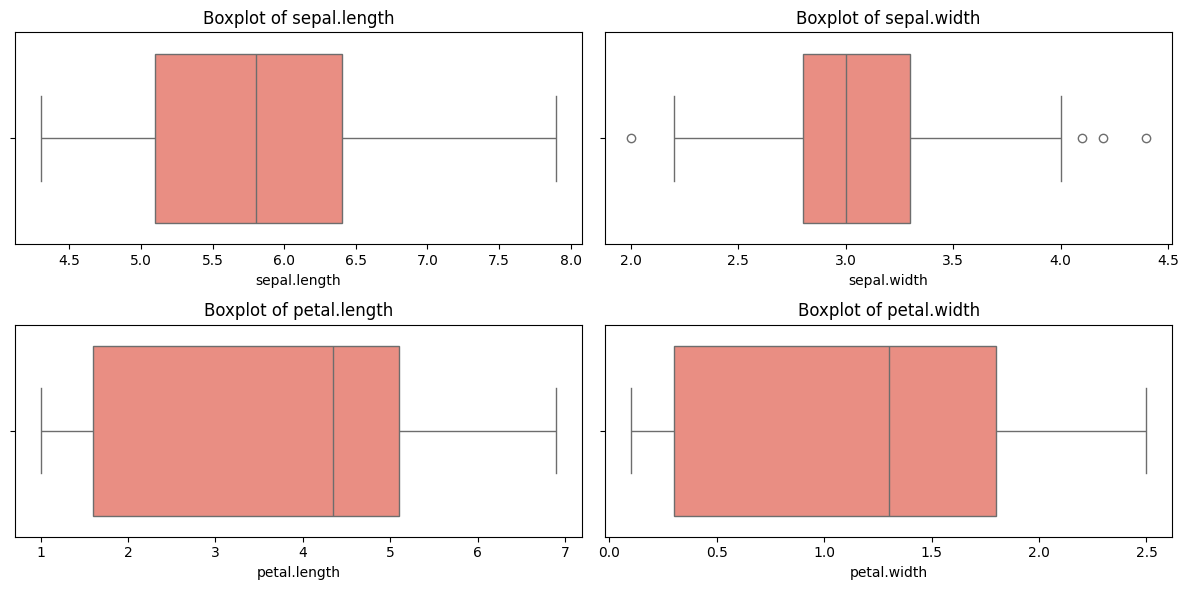

In [5]:
# Boxplot (for identifying outliers in this case)
plt.figure(figsize=(12, 6))
for i, column in enumerate(df.columns[:-1]):  # Exclude 'species' column
    ax = plt.subplot(2, 2, i + 1)
    # Create boxplot and store it in a container
    box_container = sns.boxplot(x=df[column], ax=ax, color='salmon')
    plt.title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

A boxplot visually represents the distribution of a dataset using five 
key statistics: minimum, first quartile (Q1), median (Q2), third 
quartile (Q3), and maximum, with potential outliers shown as individual 
points.

In [6]:
# Detecting outliers
for column in df.columns[:-1]:  # Exclude 'species' column
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]

    print(f"\nFeature: {column}")
    print(f"  Mean: {df[column].mean():.2f}, Median: {df[column].median():.2f}, Std Dev: {df[column].std():.2f}")
    print(f"  Outliers Detected: {'Yes' if not outliers.empty else 'No'}","\n  " f"Outlier Values: {outliers.tolist()}" if not outliers.empty else "")
    print("-" * 40)


Feature: sepal.length
  Mean: 5.84, Median: 5.80, Std Dev: 0.83
  Outliers Detected: No 
----------------------------------------

Feature: sepal.width
  Mean: 3.06, Median: 3.00, Std Dev: 0.44
  Outliers Detected: Yes 
  Outlier Values: [4.4, 4.1, 4.2, 2.0]
----------------------------------------

Feature: petal.length
  Mean: 3.76, Median: 4.35, Std Dev: 1.77
  Outliers Detected: No 
----------------------------------------

Feature: petal.width
  Mean: 1.20, Median: 1.30, Std Dev: 0.76
  Outliers Detected: No 
----------------------------------------


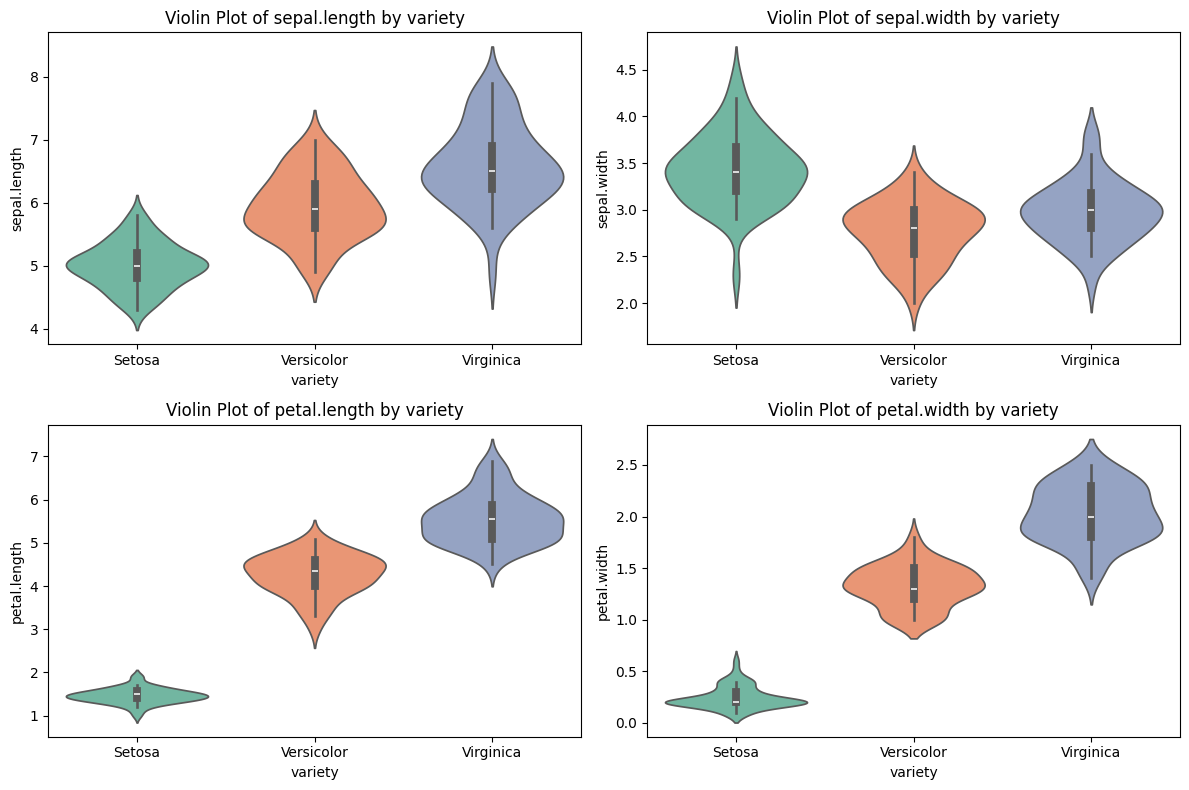

In [11]:
# Violin plot
plt.figure(figsize=(12, 8))
for i, column in enumerate(df.columns[:-1]):  # Exclude 'species' column
    plt.subplot(2, 2, i + 1)
    sns.violinplot(x=df["variety"], y=df[column], palette="Set2", hue=df['variety'])
    plt.title(f"Violin Plot of {column} by variety")

plt.tight_layout()
plt.show()

A violin plot combines a boxplot with a density plot, showing the 
distribution, median, quartiles, and the overall shape of the data.

---

**Conclusion**

1. The Iris dataset consists of four numerical features (sepal length, sepal width, petal length, and petal width) and one categorical feature (variety), which includes three classes: Setosa, Versicolor, and Virginica.

2. Histograms and boxplots revealed the distribution of each feature, with sepal width showing some outliers, identified using the IQR method.

3. Violin plots demonstrated the variation of different features across species, showing that Setosa is distinct from the other two species, while Versicolor and Virginica overlap in some features.

The analysis helped visualize data distribution, identify outliers, and understand feature relationships, providing insights for further classification tasks.

---